In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns

In [18]:
df = pd.read_csv('../data/raw-diabetes.csv')
df.head()
df.shape
df.info()
df.duplicated().sum()

missing = df.isnull().sum()
missing[missing > 0]
df["Diabetes_012"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

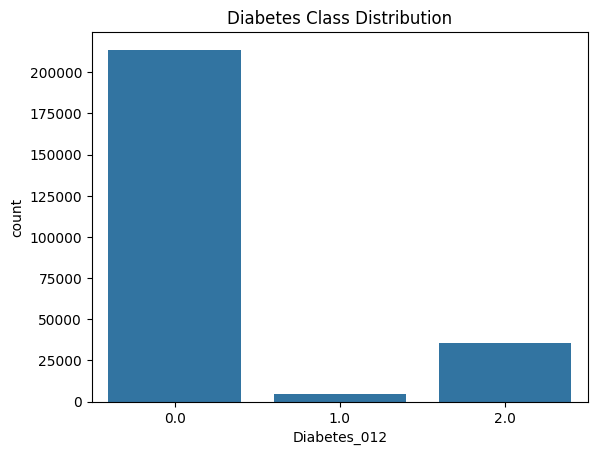

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [19]:
sns.countplot(
    data=df,
    x="Diabetes_012"
)

plt.title("Diabetes Class Distribution")
plt.show()

df.describe().T

Diabetes_012 [0. 2. 1.]
HighBP [1. 0.]
HighChol [1. 0.]
CholCheck [1. 0.]
BMI [40. 25. 28. 27. 24. 30. 34. 26. 33. 21.]
Smoker [1. 0.]
Stroke [0. 1.]
HeartDiseaseorAttack [0. 1.]
PhysActivity [0. 1.]
Fruits [0. 1.]
Veggies [1. 0.]
HvyAlcoholConsump [0. 1.]
AnyHealthcare [1. 0.]
NoDocbcCost [0. 1.]
GenHlth [5. 3. 2. 4. 1.]
MentHlth [18.  0. 30.  3.  5. 15. 10.  6. 20.  2.]
PhysHlth [15.  0. 30.  2. 14. 28.  7. 20.  3. 10.]
DiffWalk [1. 0.]
Sex [0. 1.]
Age [ 9.  7. 11. 10.  8. 13.  4.  6.  2. 12.]
Education [4. 6. 3. 5. 2. 1.]
Income [3. 1. 8. 6. 4. 7. 2. 5.]


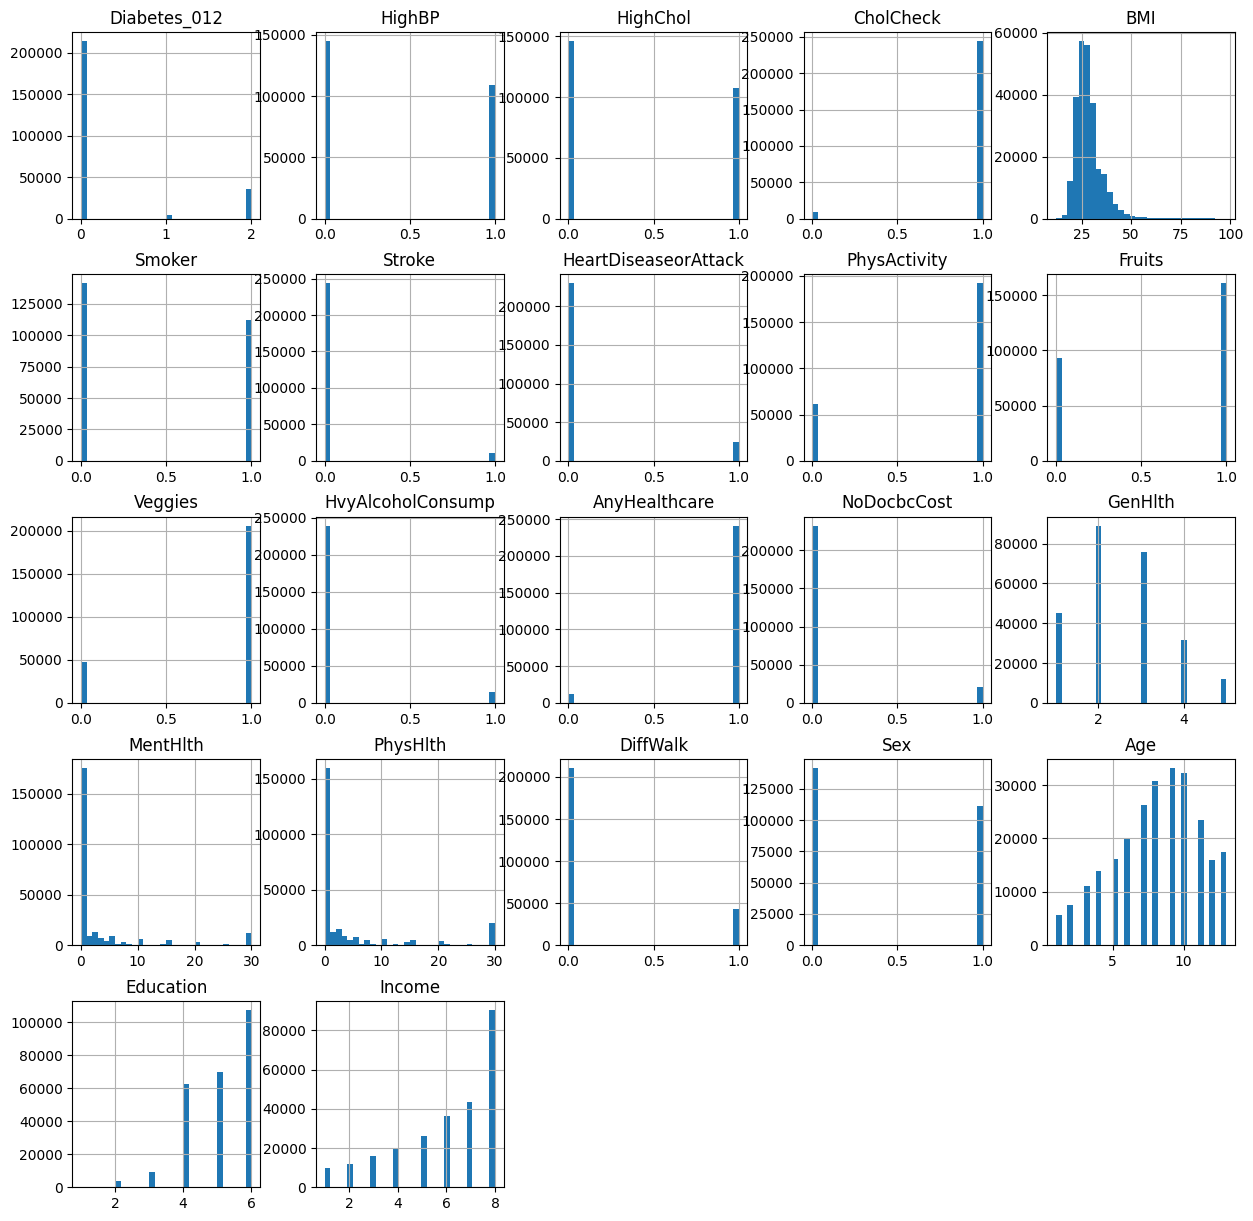

In [20]:
for col in df.columns:
    print(col, df[col].unique()[:10])
    
df.hist(
    figsize=(15,15),
    bins=30
)

plt.show()    

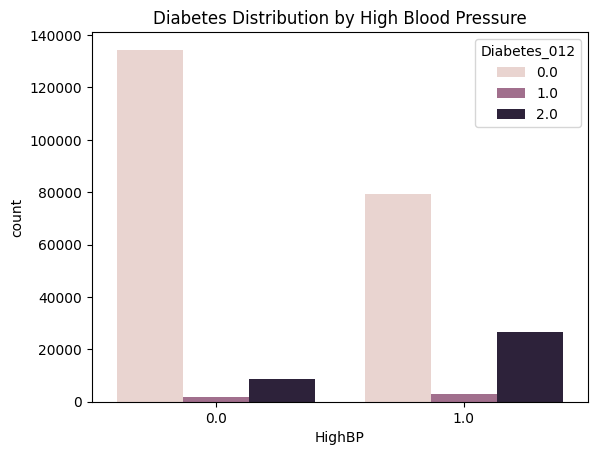

HighBP
0.0    0.132564
1.0    0.515681
Name: Diabetes_012, dtype: float64

In [25]:
sns.countplot(
    data=df,
    x="HighBP",
    hue="Diabetes_012"
)

plt.title("Diabetes Distribution by High Blood Pressure")
plt.show()

df.groupby("HighBP")["Diabetes_012"].mean()